# Lassa Fever (2020-2025)

https://ncdc.gov.ng/diseases/sitreps/?cat=5&name=An%20update%20of%20Lassa%20fever%20outbreak%20in%20Nigeria

## Loading Primary Dataset & Functions

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from statsmodels.tsa.seasonal import seasonal_decompose

def transform_df(df):
    try:
        df['year_month'] = df['week_end_date'].dt.strftime("%Y-%B")
        df['month'] = df['week_end_date'].dt.strftime("%B")
        df["season"] = df["month"].apply(
            lambda x: "Dry" if x in [
                "November", "December",
                "January", "February", 
                "March", "April"] 
            else "Rainy"
            )
    except Exception as e:
        print(f"Error in transforming date columns: {e}")
    return df

def calculate_cfr(df):
    try:
        df['cfr'] = round(df['deaths'] / df['confirmed_cases'] * 100, 2)
    except Exception as e:
        print(f"Error in calculating CFR: {e}")

    return df

def extract_yearend_reports(df: pd.DataFrame) -> str:
    try:
        end_years = df[df['epi_week'].isin([52,53])]
        end_year_urls = [url for url in end_years['report_pdf_url']][1:]
        return end_year_urls
    except Exception as e:
        print(f"Error: {e}")

def download_yearend_reports(urls: list):
    try:
        for year, url in zip(range(2020,2026), urls):
            file_name = f"{year}_yearend_report.pdf"

            with requests.get(url, stream=True, timeout=30) as resp:

                if resp.status_code == 200:
                    with open(f"yearend_reports/{file_name}", "wb") as f:
                        for chunk in resp.iter_content(chunk_size=8192):
                            if chunk:
                                f.write(chunk)
                    print(f"Downloaded: {file_name}")
                else:
                    print(f"Error downloading {file_name} Status code: {resp.status_code}")
    except Exception as e:
        print(f"Error: {e}")

def combine_year_end_data(folder_path: str):
    try:
        all_files = [os.path.join(folder_path, f) 
                    for f in os.listdir(folder_path) if f.endswith('.csv')]
        dfs = []
        for file in all_files:
            df = pd.read_csv(file)
            dfs.append(df)

        combined_df = pd.concat(dfs, ignore_index=True)
        combined_df.to_csv(r"..\data_files\final_datasets\initial_df.csv", index=False)
        return combined_df
    except Exception as e:
        print(f"Error: {e}")

def year_perc_change(df: pd.DataFrame):

    try:
        year_summary = df.groupby('epi_year')[['suspected_cases','confirmed_cases', 'deaths']].sum().reset_index()
        year_summary['rate'] = round(year_summary['deaths'] / year_summary['confirmed_cases'] * 100, 2)
        year_summary['yearly_confirmed_cases_pct_change'] = (
            year_summary['confirmed_cases'].pct_change(
            ).fillna(0).apply(
                lambda x: round(x * 100, 2))
            )
        return year_summary
    except KeyError:
        year_summary = df.groupby('Year')[['Suspected', 'Confirmed', 'Deaths']].sum().reset_index()
        year_summary['rate'] = round(year_summary['Deaths'] / year_summary['Confirmed'] * 100, 2)
        year_summary['yearly_confirmed_cases_pct_change'] = (
            year_summary['Confirmed'].pct_change(
            ).fillna(0).apply(
                lambda x: round(x * 100, 2))
            )
        return year_summary
    except Exception as e:
        print(f"Error: {e}")

def period_summary(df: pd.DataFrame, col: str):

    for cols in df.columns:
        if col and 'suspected_cases' and 'confirmed_cases' and 'deaths' in df.columns:
            continue
        else:
            break
    try:
        summary = df.groupby(col)[['suspected_cases','confirmed_cases',
                            'probable_cases', 'deaths']].sum().reset_index()
        summary['cfr'] = round(summary['deaths'] / summary['confirmed_cases'] * 100,2)
    except Exception as e:
        print(f"Error: {e}")
    return summary

def year_epid_trend_chart(df: pd.DataFrame):
    
    for col in df.columns:
        if 'epi_year' and 'confirmed_cases' and 'deaths' in df.columns:
            continue            
        else:
            break
    df = df.sort_values("epi_year")

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(
        df["epi_year"],
        df["confirmed_cases"],
        marker="o",
        label="Confirmed cases"
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Confirmed cases")
    ax1.tick_params(axis="y")

    ax2 = ax1.twinx()
    ax2.plot(
        df["epi_year"],
        df["deaths"],
        marker="o",
        linestyle="--",
        label="Deaths"
    )
    ax2.set_ylabel("Deaths")
    ax2.tick_params(axis="y")

    plt.title("Yearly Trends in Confirmed Lassa Fever Cases and Deaths (2020–2025)")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    plt.tight_layout()
    plt.show()

def month_epid_trend_chart(df: pd.DataFrame):
    for col in df.columns:
        if 'month' and 'confirmed_cases' and 'deaths' in df.columns:
            continue            
        else:
            break

    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]

    df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)
    df = df.sort_values("month")

    fig, ax1 = plt.subplots(figsize=(11, 6))
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    ax1.plot(
        df["month"],
        df["confirmed_cases"],
        marker="o",
        label="Confirmed cases"
    )
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Confirmed cases")

    ax2 = ax1.twinx()
    ax2.plot(
        df["month"],
        df["deaths"],
        marker="o",
        linestyle="--",
        label="Deaths"
    )
    ax2.set_ylabel("Deaths")

    plt.title("Monthly Trends in Confirmed Lassa Fever Cases and Deaths (2020–2025)")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.tight_layout()
    plt.show()

def quarter_epid_trend_chart(df: pd.DataFrame):
    for col in df.columns:
        if 'quarter' and 'confirmed_cases' and 'deaths' in df.columns:
            continue            
        else:
            break

    x = np.arange(len(df["quarter"]))
    width = 0.40

    plt.figure(figsize=(10, 6))
    plt.bar(x, df["confirmed_cases"], width, label="confirmed_cases")
    plt.bar(x + width, df["deaths"], width, label="deaths")

    plt.xlabel("Quarter")
    plt.ylabel("Number of cases")
    plt.title("Quarterly Distribution of Lassa Fever Cases and Deaths (2020–2025)")
    plt.xticks(x, df["quarter"])
    plt.legend()

    plt.tight_layout()
    plt.show()

def weekly_seasonal_decomposition(df: pd.DataFrame, col='date'):

    for cols in df.columns:
        if col in df.columns:
            continue
        else:
            break

    df[col] = pd.date_range(
        start="2020-01-01", periods=len(df), freq="W"
    )

    df.set_index(col, inplace=True)

    decomposition = seasonal_decompose(
        df["confirmed_cases"],
        model="additive",
        period=12
    )

    decomposition.plot()
    plt.suptitle(
        "Seasonal Decomposition of Weekly Confirmed Lassa Fever Cases (2020–2025)",
        y=1.02
    )
    plt.tight_layout()
    plt.show()


### Load Dataset

In [2]:
file_path = r'..\data_files\lassa_fever_updated.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# Study Aim/Goal
- To analyse the trends of Lassa fever outbreaks in Nigeria from 2020 to 2025. 

The specific objectives 
- To describe annual and seasonal patterns of confirmed cases and deaths. 
- To assess changes in geographic distribution over time.
- To examine trends in key epidemiological indicators across this five-year period. 


## Data Cleaning and Transformation Process

### Initial Transformation

In [3]:
trans_df = transform_df(df)

### Extracting Year End Documents Urls

In [ ]:
end_year_urls = extract_yearend_reports(trans_df)
print(end_year_urls)

### Downloading Year End Cumulative Data

In [5]:
download_yearend_reports(urls=end_year_urls)

Error downloading 2020_yearend_report.pdf. Status code: 522
Error downloading 2021_yearend_report.pdf. Status code: 522
Error downloading 2022_yearend_report.pdf. Status code: 522
Downloaded: 2023_yearend_report.pdf
Error downloading 2024_yearend_report.pdf. Status code: 522
Downloaded: 2025_yearend_report.pdf


### Combining Year End Cumulative Data

In [6]:
folder_path = r"..\data_files\year_end_tables"
combined_df = combine_year_end_data(folder_path=folder_path)

In [7]:
combined_df = combined_df.rename(columns={'HCW (Confirmed Case)': 'Confirmed HCW Cases',
                    'Deaths (Confirmed Cases)': 'Deaths'})
combined_df.head(2)

,Year,State,Suspected,Confirmed,Probable,Confirmed HCW Cases,Deaths
0,2020,Abia,62,5,0,0,2
1,2020,Adamawa,21,4,0,0,1


# Objective 1 - To describe annual and seasonal patterns

## Analytics

The first objective, 
- to determine the annual and seasonal pattern, was performed with the following analysis: 
   + descriptive statistics (frequencies, percentages, rates), 
   + time-series plots of confirmed cases and deaths, 
   + seasonal decomposition analysis, and 
   + monthly and quarterly trend analysis

### Frequencies

In [8]:
count_cols = [
    "suspected_cases",
    "confirmed_cases",
    "probable_cases",
    "deaths"
]

summary_dict = trans_df[count_cols].sum().to_dict()


summary_df = (
    trans_df[count_cols]
    .sum()
    .reset_index()
    .rename(columns={"index": "Indicator", 0: "Total"})
)
summary_df

,Indicator,Total
0,suspected_cases,47814
1,confirmed_cases,6456
2,probable_cases,53
3,deaths,1008


### Yearly & Season Summaries

In [9]:
year_summary = year_perc_change(df=trans_df)

### General Overview of Years, Seasons, Quarters and Months

In [10]:
df_trans = trans_df.copy()
df_trans['quarter'] = df_trans['week_end_date'].dt.quarter

In [11]:
season_summ = period_summary(df=df_trans,  col='season')

month_summ = period_summary(df=df_trans, col='month')

year_summ = period_summary(df=df_trans, col='epi_year')

quarter_summ = period_summary(df=df_trans, col='quarter')


## Charts

### Yearly Trends in Confirmed Lassa Fever Cases and Deaths (2020–2025)

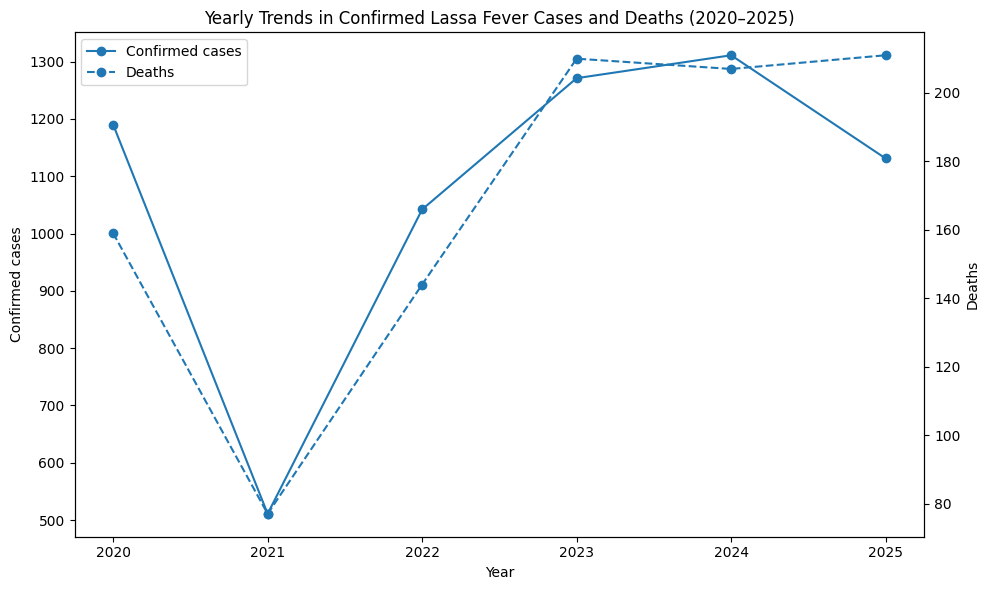

In [12]:
year_epid_trend_chart(df=year_summ)

### Monthly Trends in Confirmed Lassa Fever Cases and Deaths (2020–2025)

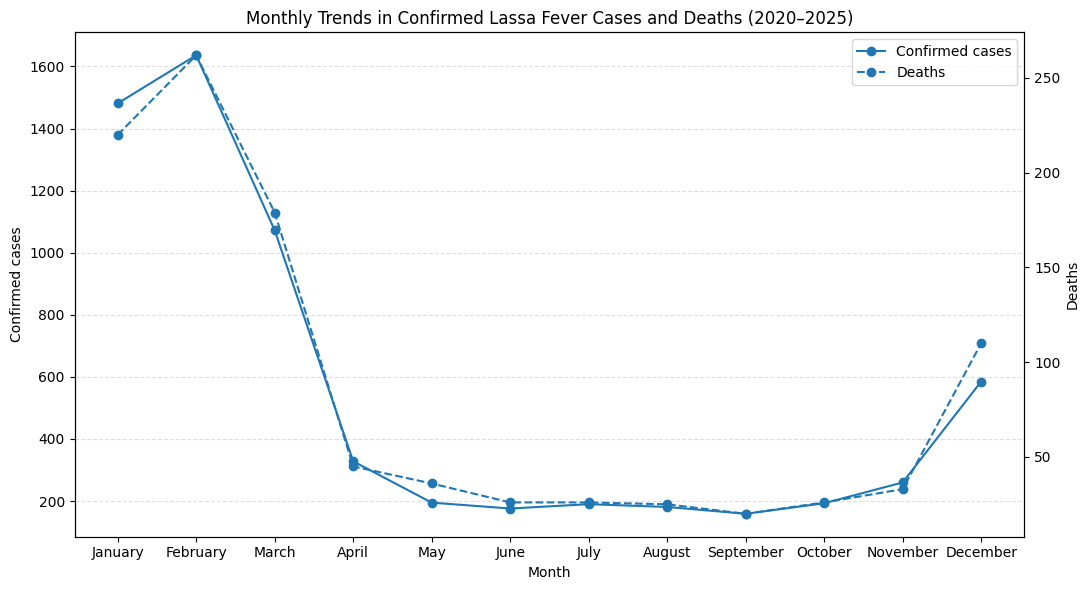

In [13]:
month_epid_trend_chart(df=month_summ)

### Quarterly Distribution of Lassa Fever Cases and Deaths (2020–2025)

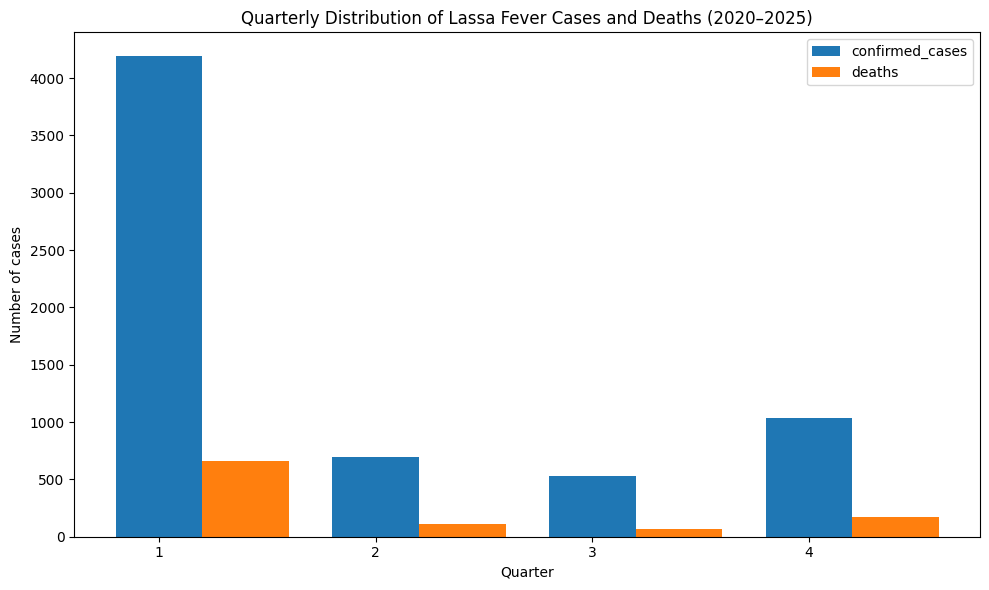

In [14]:
quarter_epid_trend_chart(df=quarter_summ)

### Seasonal Decomposition of Weekly Confirmed Lassa Fever Cases (2020–2025)

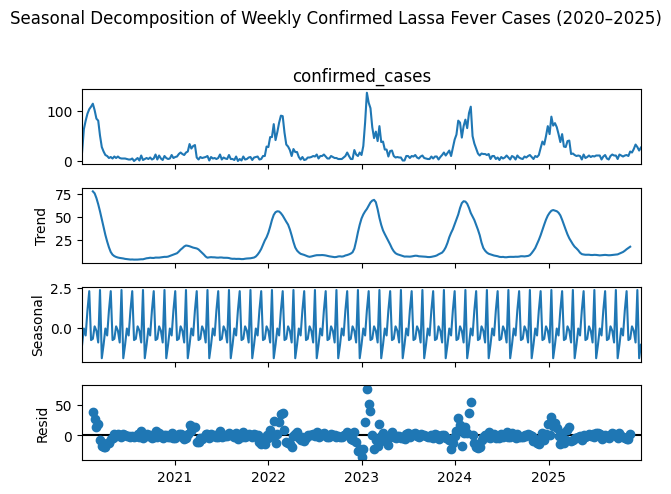

In [15]:
weekly_seasonal_decomposition(df=df_trans)

# Objective 2 - To assess changes in geographic distribution over time.

In [16]:
import pandas as pd
import geopandas as gpd

### Functions

In [ ]:
def states_data_comparison(df_1: pd.DataFrame, df_2: gpd.GeoDataFrame):
    if 'state_clean' in df_1.columns and 'state_clean' in df_2.columns:
        comparison = pd.DataFrame({
            "cases_states": sorted(df_1['state_clean'].unique()),
        }).merge(
            pd.DataFrame({"shape_states": sorted(df_2['state_clean'].unique())}),
            left_on='cases_states',
            right_on='shape_states',
            how='outer',
            indicator=True
        )
    else:
        print("Check the dataframes inserted! " \
        "\ndf_1: states summary lassa_fever data" \
        "\ndf_2: geom_shape data")

    return comparison


def clean_state(x):
    return (
        str(x).strip()
    )





### Loading States Yearly Data (2020-2026)

In [17]:
states_filepath = r"..\data_files\final_datasets\initial_df.csv"
nigeria_shapefile = r"..\data_files\nga_admin_boundaries\nga_admin1_em.shp"

gdf_1 = gpd.read_file(nigeria_shapefile)
states_df = pd.read_csv(states_filepath)

### Cleaning and Transformation

In [18]:
gdf_clean = gdf_1.dropna(axis=1, how='all')

gdf_clean = gdf_clean.rename(columns={'adm1_name': 'state', 'adm1_pcode': 'state_pcode',
                          'adm0_name': 'country', 'adm0_pcode': 'country_pcode',
                          })

states_df = states_df.rename(columns={'Year': 'year', 'State': 'state',
                          'Suspected': 'suspected', 'Confirmed': 'confirmed',
                          'Probable': 'probable', 'HCW (Confirmed Case)': 'confirmed_HCW_cases',
                          'Deaths (Confirmed Cases)': 'deaths'})

In [19]:
lassa_state_list = list(states_df['state'].unique())
shapefile_state_list = list(gdf_clean['state'].unique())

In [ ]:
gdf_clean['state_clean'] = gdf_clean['state'].apply(clean_state)
gdf_clean['state_clean'] = gdf_clean['state_clean'].replace('Federal Capital Territory',  'FCT')

states_df = states_df[states_df['state'] != 'Jos']
states_df['state_clean'] = states_df['state'].apply(clean_state)

In [51]:
states_data_comparison(df_1=states_df,
                       df_2=gdf_clean)

,cases_states,shape_states,_merge
0,Abia,Abia,both
1,Adamawa,Adamawa,both
2,Akwa Ibom,Akwa Ibom,both
3,Anambra,Anambra,both
4,Bauchi,Bauchi,both
5,Bayelsa,Bayelsa,both
6,Benue,Benue,both
7,Borno,Borno,both
8,Cross River,Cross River,both
9,Delta,Delta,both


In [ ]:
states_summ_df = states_df.groupby(['state_clean'])[['suspected', 'confirmed',
                                                    'probable', 'confirmed_HCW_cases', 'deaths']].sum().reset_index()
gdf_summ = gdf_clean.merge(states_summ_df, on='state_clean', how='left')

gdf_map = gdf_clean.merge(states_df, on="state_clean", how="left")
gdf_map["confirmed"] = gdf_map["confirmed"].fillna(0)

,state_clean,suspected,confirmed,probable,confirmed_HCW_cases,deaths
0,Abia,148,6,0,0,2
1,Adamawa,98,9,0,0,1


In [24]:
gdf_summ.head(2)

,state,state_pcode,country,country_pcode,valid_on,area_sqkm,version,lang,center_lat,center_lon,geometry,state_clean,suspected,confirmed,probable,confirmed_HCW_cases,deaths
0,Abia,NG001,Nigeria,NG,2019-04-17,4859.503138,v01,en,5.431820,7.488342,"POLYGON ((7.38681 6.03667, 7.38729 6.03605, 7....",Abia,148,6,0,0,2
1,Adamawa,NG002,Nigeria,NG,2019-04-17,37971.674279,v01,en,9.140949,12.295110,"POLYGON ((13.62129 10.94823, 13.62592 10.94822...",Adamawa,98,9,0,0,1


In [25]:
gdf_map.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   state_x              222 non-null    str           
 1   state_pcode          222 non-null    str           
 2   country              222 non-null    str           
 3   country_pcode        222 non-null    str           
 4   valid_on             222 non-null    datetime64[ms]
 5   area_sqkm            222 non-null    float64       
 6   version              222 non-null    str           
 7   lang                 222 non-null    str           
 8   center_lat           222 non-null    float64       
 9   center_lon           222 non-null    float64       
 10  geometry             222 non-null    geometry      
 11  state_clean          222 non-null    str           
 12  year                 222 non-null    int64         
 13  state_y              222 no

In [26]:
gdf_summ.groupby(['state_clean'])[['suspected', 'confirmed',
                                    'probable', 'confirmed_HCW_cases', 'deaths']].sum().reset_index().head(2)



,state_clean,suspected,confirmed,probable,confirmed_HCW_cases,deaths
0,Abia,148,6,0,0,2
1,Adamawa,98,9,0,0,1


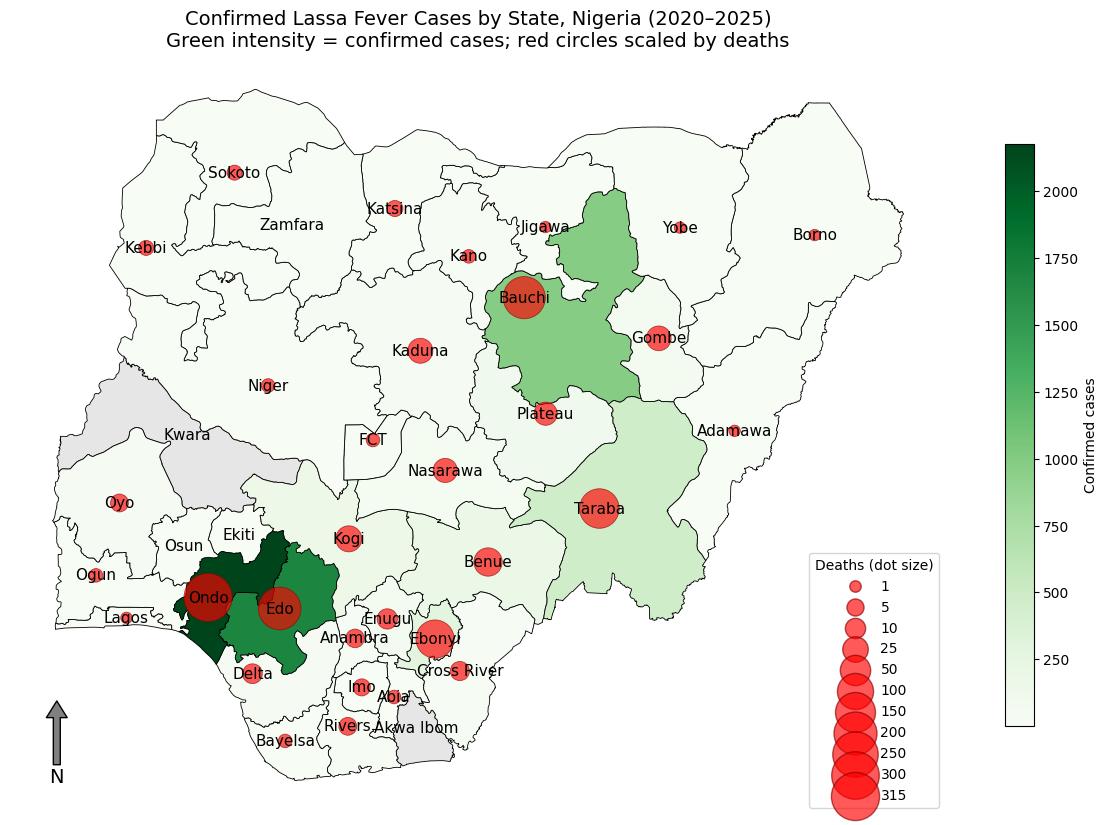

In [27]:
import numpy as np
import matplotlib.pyplot as plt

STATE_LABEL_COL = "state_clean"

if gdf_summ.crs is not None and gdf_summ.crs.to_epsg() != 4326:
    gdf_plot = gdf_summ.to_crs(epsg=4326)
else:
    gdf_plot = gdf_summ.copy()

gdf_plot["pt"] = gdf_plot.geometry.representative_point()
gdf_plot["x"] = gdf_plot["pt"].x
gdf_plot["y"] = gdf_plot["pt"].y

gdf_plot["has_confirmed"] = gdf_plot["confirmed"].fillna(0) > 0
gdf_plot["has_deaths"] = gdf_plot["deaths"].fillna(0) > 0

dots = gdf_plot[gdf_plot["has_deaths"]].copy()
sum_deaths = float(dots["deaths"].max()) if len(dots) else 1.0

MAX_DOT_AREA = 1200
dots["dot_size"] = (np.sqrt(dots["deaths"]) / np.sqrt(sum_deaths)) * MAX_DOT_AREA

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_plot[~gdf_plot["has_confirmed"]].plot(
    ax=ax, color="#e6e6e6", edgecolor="black", linewidth=0.6
)

gdf_plot[gdf_plot["has_confirmed"]].plot(
    ax=ax,
    column="confirmed",
    cmap="Greens",
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    legend_kwds={"label": "Confirmed cases", "shrink": 0.6}
)

ax.scatter(
    dots["x"], dots["y"],
    s=dots["dot_size"],
    color="red",
    alpha=0.65,
    edgecolors="darkred",
    linewidths=0.6,
    zorder=3
)

for _, row in gdf_plot.iterrows():
    ax.text(
        row["x"], row["y"],
        str(row[STATE_LABEL_COL]),
        fontsize=11,
        ha="center", va="center",
        zorder=4
    )

legend_breaks = [1, 5, 10, 25, 50, 100, 150, 200, 250, 300, int(sum_deaths)]
legend_breaks = sorted(set([b for b in legend_breaks if 0 < b <= sum_deaths]))

legend_sizes = [(np.sqrt(v) / np.sqrt(sum_deaths)) * MAX_DOT_AREA for v in legend_breaks]
handles = [plt.scatter([], [], s=s, color="red", alpha=0.65, edgecolors="darkred") for s in legend_sizes]

ax.legend(
    handles,
    [str(v) for v in legend_breaks],
    title="Deaths (dot size)",
    loc="lower right",
    frameon=True
)

ax.set_title(
    "Confirmed Lassa Fever Cases by State, Nigeria (2020–2025)\n"
    "Green intensity = confirmed cases; red circles scaled by deaths",
    fontsize=14
)

ax.annotate(
    "N",
    xy=(0.05, 0.15),
    xytext=(0.05, 0.05),
    arrowprops=dict(
        facecolor="Grey",
        width=5,
        headwidth=15
    ),
    ha="center",
    va="center",
    fontsize=14,
    xycoords=ax.transAxes
)
ax.axis("off")
plt.tight_layout()
plt.show()


In [28]:
zone_map = {
    # North Central
    "Benue": "North Central",
    "FCT": "North Central",
    "Kogi": "North Central",
    "Kwara": "North Central",
    "Nasarawa": "North Central",
    "Niger": "North Central",
    "Plateau": "North Central",

    # North East
    "Adamawa": "North East",
    "Bauchi": "North East",
    "Borno": "North East",
    "Gombe": "North East",
    "Taraba": "North East",
    "Yobe": "North East",

    # North West
    "Jigawa": "North West",
    "Kaduna": "North West",
    "Kano": "North West",
    "Katsina": "North West",
    "Kebbi": "North West",
    "Sokoto": "North West",
    "Zamfara": "North West",

    # South East
    "Abia": "South East",
    "Anambra": "South East",
    "Ebonyi": "South East",
    "Enugu": "South East",
    "Imo": "South East",

    # South South
    "Akwa Ibom": "South South",
    "Bayelsa": "South South",
    "Cross River": "South South",
    "Delta": "South South",
    "Edo": "South South",
    "Rivers": "South South",

    # South West
    "Ekiti": "South West",
    "Lagos": "South West",
    "Ogun": "South West",
    "Ondo": "South West",
    "Osun": "South West",
    "Oyo": "South West"
}
gdf_summ["geo_zone"] = gdf_summ["state_clean"].map(zone_map)

unmapped = gdf_summ[gdf_summ["geo_zone"].isna()]["state_clean"].unique()
print("Unmapped states:", unmapped)


Unmapped states: <StringArray>
[]
Length: 0, dtype: str


C:\Users\APIN-PC\AppData\Local\Temp\ipykernel_25248\103642335.py:36: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  gdf_plot.plot(


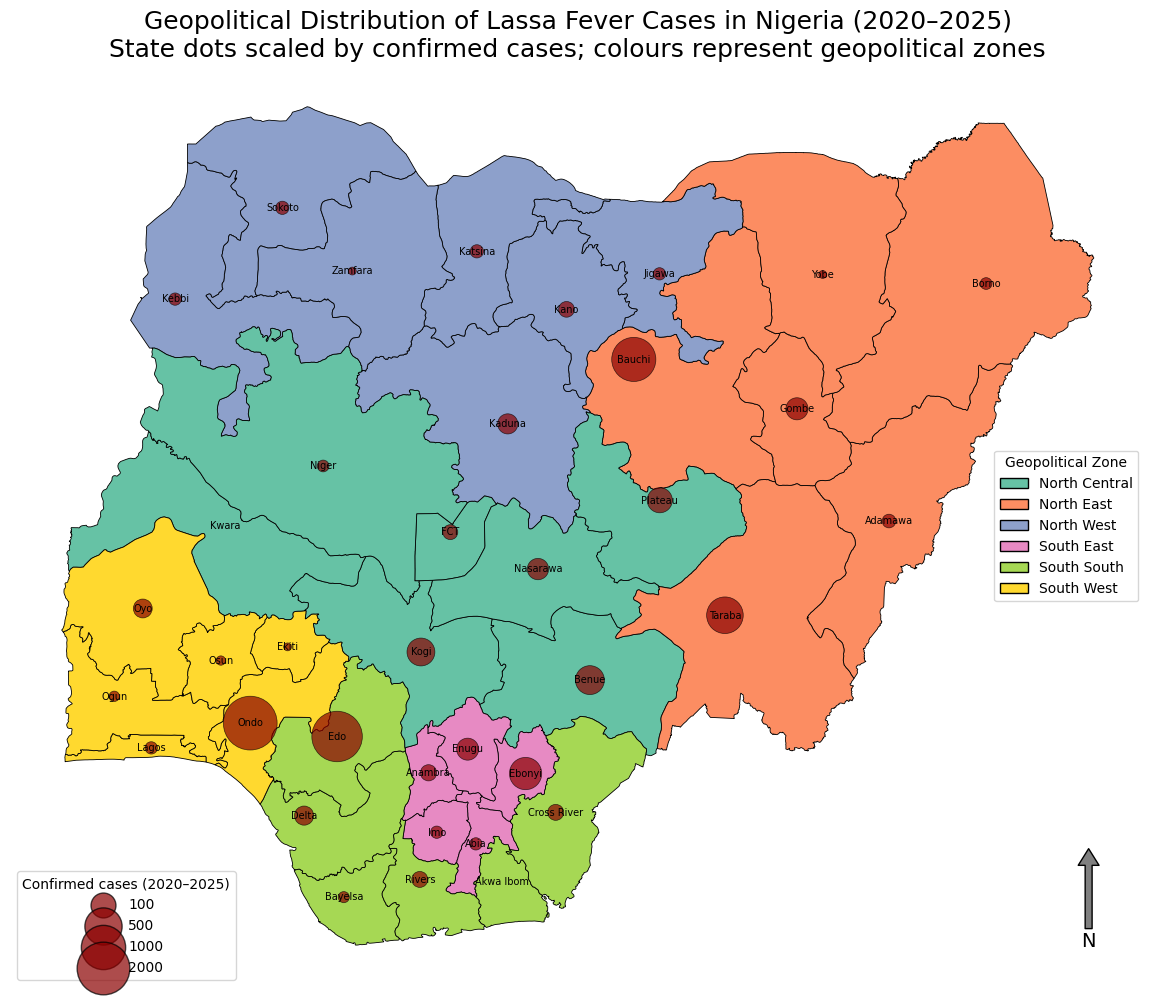

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Patch

gdf_plot = gdf_summ.copy()


zone_colors = {
    "North Central": "#66c2a5",
    "North East": "#fc8d62",
    "North West": "#8da0cb",
    "South East": "#e78ac3",
    "South South": "#a6d854",
    "South West": "#ffd92f"
}

if gdf_plot.crs is not None and gdf_plot.crs.to_epsg() != 4326:
    gdf_plot = gdf_plot.to_crs(epsg=4326)

gdf_plot["pt"] = gdf_plot.geometry.representative_point()
gdf_plot["x"] = gdf_plot["pt"].x
gdf_plot["y"] = gdf_plot["pt"].y

dots = gdf_plot[gdf_plot["confirmed"] > 0].copy()

max_confirmed = dots["confirmed"].max()
MAX_DOT_AREA = 1500

dots["dot_size"] = (
    np.sqrt(dots["confirmed"]) / np.sqrt(max_confirmed)
) * MAX_DOT_AREA

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_plot.plot(
    ax=ax,
    column="geo_zone",
    categorical=True,
    legend=False,
    color=gdf_plot["geo_zone"].map(zone_colors),
    edgecolor="black",
    linewidth=0.6
)

ax.scatter(
    dots["x"],
    dots["y"],
    s=dots["dot_size"],
    color="darkred",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.5,
    zorder=3
)

for _, row in gdf_plot.iterrows():
    ax.text(
        row["x"],
        row["y"],
        row["state_clean"],
        fontsize=7,
        ha="center",
        va="center",
        zorder=4
    )

legend_vals = [100, 500, 1000, 2000]
legend_vals = [v for v in legend_vals if v <= max_confirmed]

legend_sizes = [
    (np.sqrt(v) / np.sqrt(max_confirmed)) * MAX_DOT_AREA
    for v in legend_vals
]

dot_handles = [
    plt.scatter([], [], s=s, color="darkred", alpha=0.7, edgecolors="black")
    for s in legend_sizes
]

dot_legend = ax.legend(
    dot_handles,
    [str(v) for v in legend_vals],
    title="Confirmed cases (2020–2025)",
    loc="lower left",
    frameon=True
)

ax.add_artist(dot_legend)

zone_handles = [
    Patch(facecolor=color, edgecolor="black", label=zone)
    for zone, color in zone_colors.items()
]

zone_legend = ax.legend(
    handles=zone_handles,
    title="Geopolitical Zone",
    loc="right",
    frameon=True
)

ax.set_title(
    "Geopolitical Distribution of Lassa Fever Cases in Nigeria (2020–2025)\n"
    "State dots scaled by confirmed cases; colours represent geopolitical zones",
    fontsize=18
)

ax.annotate(
    "N",
    xy=(0.95, 0.15),
    xytext=(0.95, 0.05),
    arrowprops=dict(
        facecolor="Grey",
        width=5,
        headwidth=15
    ),
    ha="center",
    va="center",
    fontsize=14,
    xycoords=ax.transAxes
)

ax.axis("off")
plt.tight_layout()
plt.show()


In [30]:
gdf_summ.groupby(['geo_zone'])[['confirmed', 'deaths']].sum().head(2)

,confirmed,deaths
geo_zone,,
North Central,515,106
North East,1530,356


# Objective 3 - To examine trends in key epidemiological indicators across this five-year period. 

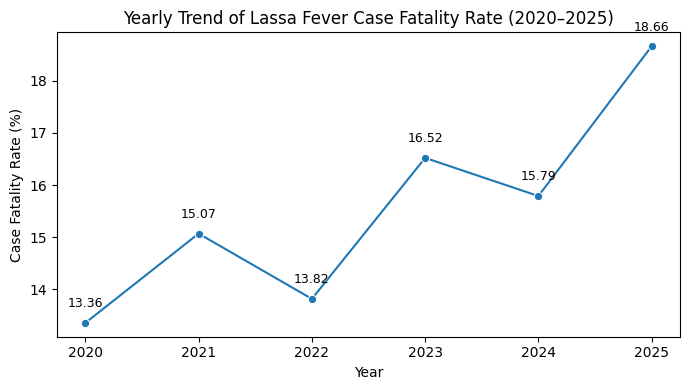

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
ax = sns.lineplot(data=year_summ, x="epi_year", y="cfr", marker="o")

# Add labels
for x, y in zip(year_summ["epi_year"], year_summ["cfr"]):
    ax.text(x, y + 0.3, f"{y:.2f}", ha='center', fontsize=9)

plt.title("Yearly Trend of Lassa Fever Case Fatality Rate (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Case Fatality Rate (%)")
plt.xticks(year_summ["epi_year"])

plt.tight_layout()
plt.show()

In [32]:
year_season_summ =df_trans.groupby(['epi_year', 'season'])[['suspected_cases','confirmed_cases',
                           'probable_cases', 'deaths']].sum().reset_index()
year_season_summ['cfr'] = round(year_season_summ['deaths'] / year_season_summ['confirmed_cases'] * 100,2)
year_season_summ.head(2)

,epi_year,season,suspected_cases,confirmed_cases,probable_cases,deaths,cfr
0,2020,Dry,5409,1057,9,135,12.77
1,2020,Rainy,1425,133,0,24,18.05


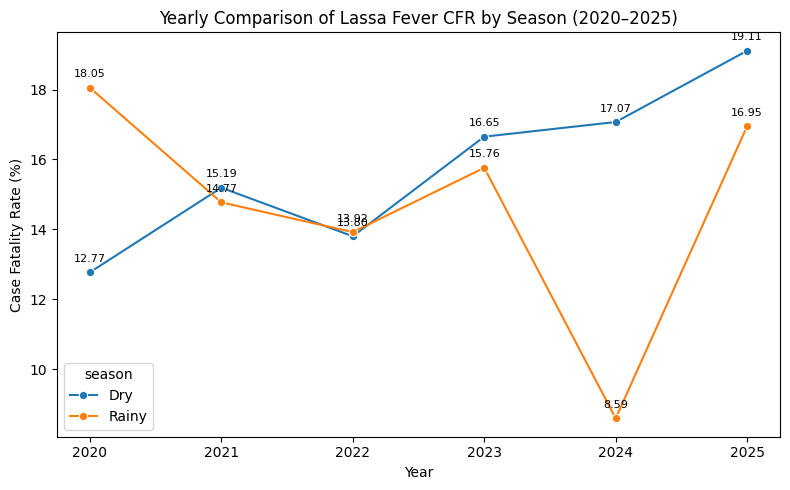

In [33]:
plt.figure(figsize=(8, 5))
ax = sns.lineplot(
    data=year_season_summ,
    x="epi_year",
    y="cfr",
    hue="season",
    marker="o"
)

for _, row in year_season_summ.iterrows():
    ax.text(row["epi_year"], row["cfr"] + 0.3, f'{row["cfr"]:.2f}',
            ha='center', fontsize=8)

plt.title("Yearly Comparison of Lassa Fever CFR by Season (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Case Fatality Rate (%)")
plt.xticks(year_season_summ["epi_year"].unique())

plt.tight_layout()
plt.show()


In [34]:
import pandas as pd

gdf_map["geo_zone"] = gdf_map["state_clean"].map(zone_map)

print(f"Unmapped: {gdf_map["geo_zone"].isna().sum()}" )


zone_year = (
    gdf_map
    .groupby(["year", "geo_zone"], as_index=False)[["confirmed", "deaths"]]
    .sum()
    .sort_values(["year", "geo_zone"])
)

zone_year


state_year = (
    gdf_map
    .groupby(['year', 'state_clean'], as_index=False)[['confirmed', 'deaths']]
    .sum()
    .sort_values(['year', 'state_clean'])
)

state_year

high_burden_state =state_year[state_year['state_clean'].isin(['Ondo', 'Edo', 'Bauchi', 
                                           'Taraba', 'Ebonyi'])].reset_index(drop=True)

high_burden_state.head(2)


Unmapped: 0


,year,state_clean,confirmed,deaths
0,2020,Bauchi,53,22
1,2020,Ebonyi,81,23


In [35]:
zone_year['cfr'] = round((zone_year['deaths']/zone_year['confirmed']) * 100, 2)

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


zone_year["cfr"] = (round(
    zone_year["deaths"] / zone_year["confirmed"]
 * 100,2))


cfr_pivot = zone_year.pivot(
    index="geo_zone",
    columns="year",
    values="cfr"
)

cfr_pivot = cfr_pivot.sort_index()

print(cfr_pivot)


year            2020   2021   2022   2023   2024   2025
geo_zone                                               
North Central  27.08   7.69  21.55  13.48  14.84  36.67
North East     37.50  39.34  20.67  23.78  21.66  19.25
North West     48.15  50.00  62.50   7.69  52.63  23.08
South East     28.57  38.46  31.58  56.25  49.33  40.00
South South    11.17   7.01  11.70  15.08  12.26  18.09
South West     19.39  26.86  15.65  11.62   7.20  13.75


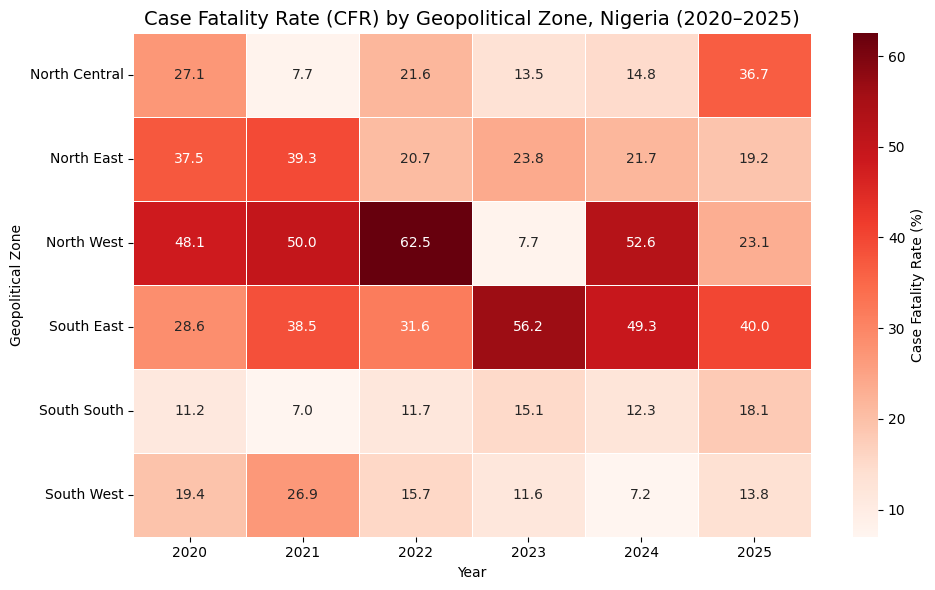

In [37]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cfr_pivot,
    annot=True,              # show CFR values
    fmt=".1f",               # 1 decimal place
    cmap="Reds",             # red gradient (higher = darker)
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Case Fatality Rate (%)"}
)

plt.title(
    "Case Fatality Rate (CFR) by Geopolitical Zone, Nigeria (2020–2025)",
    fontsize=14
)

plt.ylabel("Geopolitical Zone")
plt.xlabel("Year")

plt.tight_layout()
plt.show()


In [38]:
high_burden_state['cfr'] = round((high_burden_state['deaths']/high_burden_state['confirmed']) * 100,2)
high_burden_state.to_csv(r"..\data_files\final_datasets\high_burden_states.csv", index=False)

cfr_pivot_states = high_burden_state.pivot(
    index="state_clean",
    columns="year",
    values="cfr"
)

cfr_pivot_states = cfr_pivot_states.sort_index()

print(cfr_pivot_states)

year          2020   2021   2022   2023   2024   2025
state_clean                                          
Bauchi       41.51  30.77  13.70  19.59  21.74  13.29
Ebonyi       28.40  50.00  41.67  56.36  54.72  46.43
Edo          10.39   7.08  10.62  14.33  10.38  16.94
Ondo         19.62  26.86  15.52  11.55   6.75  13.57
Taraba       37.93  54.55  40.54  31.37  20.54  29.41


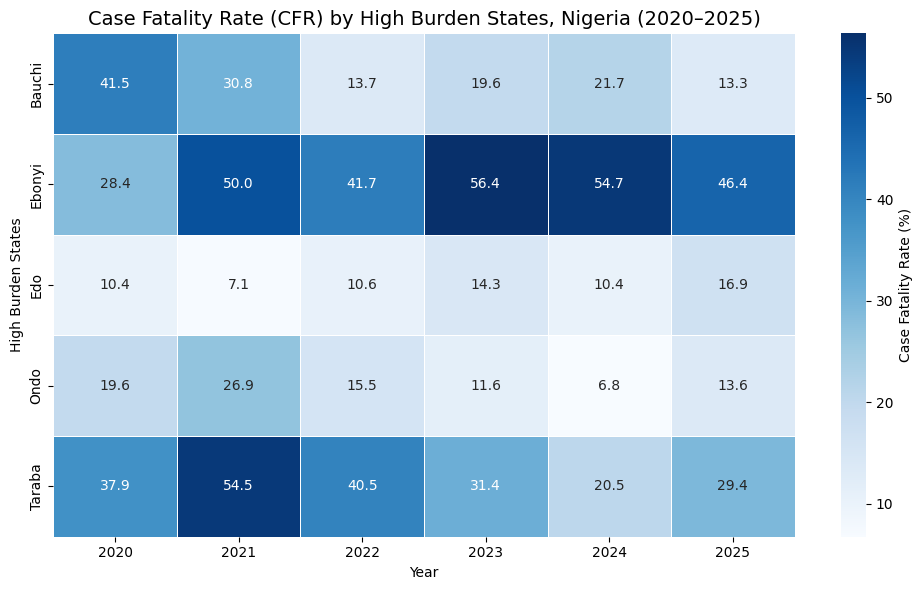

In [39]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cfr_pivot_states,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Case Fatality Rate (%)"}
)

plt.title(
    "Case Fatality Rate (CFR) by High Burden States, Nigeria (2020–2025)",
    fontsize=14
)

plt.ylabel("High Burden States")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

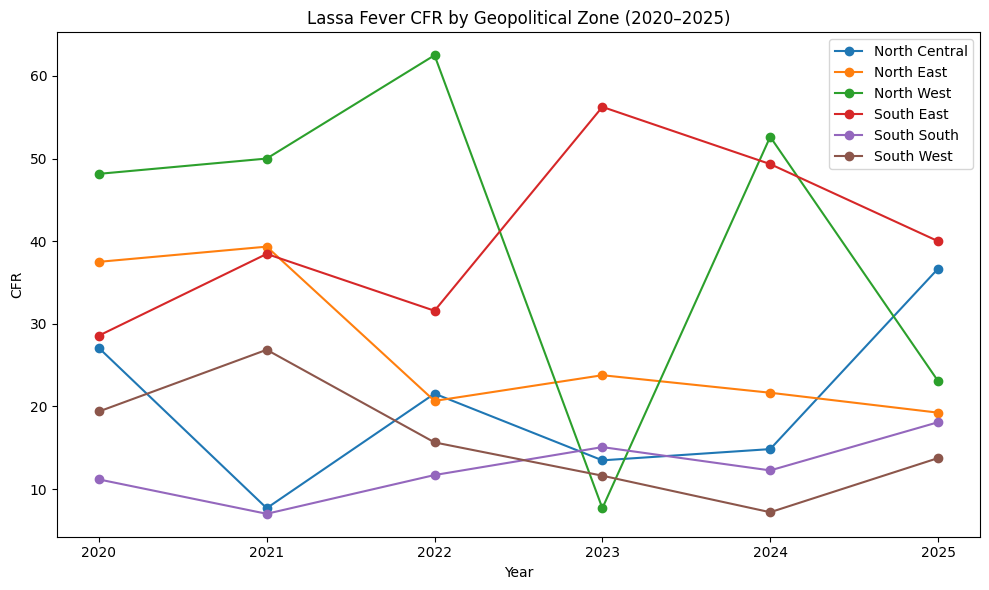

In [40]:
import matplotlib.pyplot as plt

pivot_confirmed = zone_year.pivot(index="year", columns="geo_zone", values="cfr")

plt.figure(figsize=(10,6))
for zone in pivot_confirmed.columns:
    plt.plot(pivot_confirmed.index, pivot_confirmed[zone], marker="o", label=zone)


plt.xlabel("Year")
plt.ylabel("CFR")
plt.title("Lassa Fever CFR by Geopolitical Zone (2020–2025)")
plt.legend()
plt.xticks(pivot_confirmed.index)
plt.tight_layout()
plt.show()


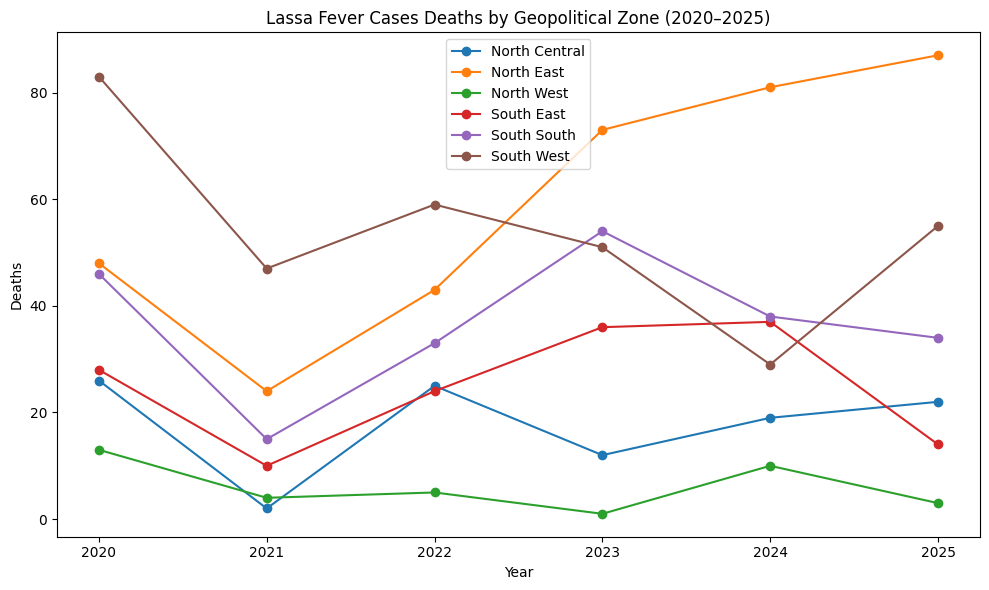

In [41]:
import matplotlib.pyplot as plt

pivot_confirmed = zone_year.pivot(index="year", columns="geo_zone", values="deaths")

plt.figure(figsize=(10,6))
for zone in pivot_confirmed.columns:
    plt.plot(pivot_confirmed.index, pivot_confirmed[zone], marker="o", label=zone)

plt.xlabel("Year")
plt.ylabel("Deaths")
plt.title("Lassa Fever Cases Deaths by Geopolitical Zone (2020–2025)")
plt.legend()
plt.xticks(pivot_confirmed.index)
plt.tight_layout()
plt.show()


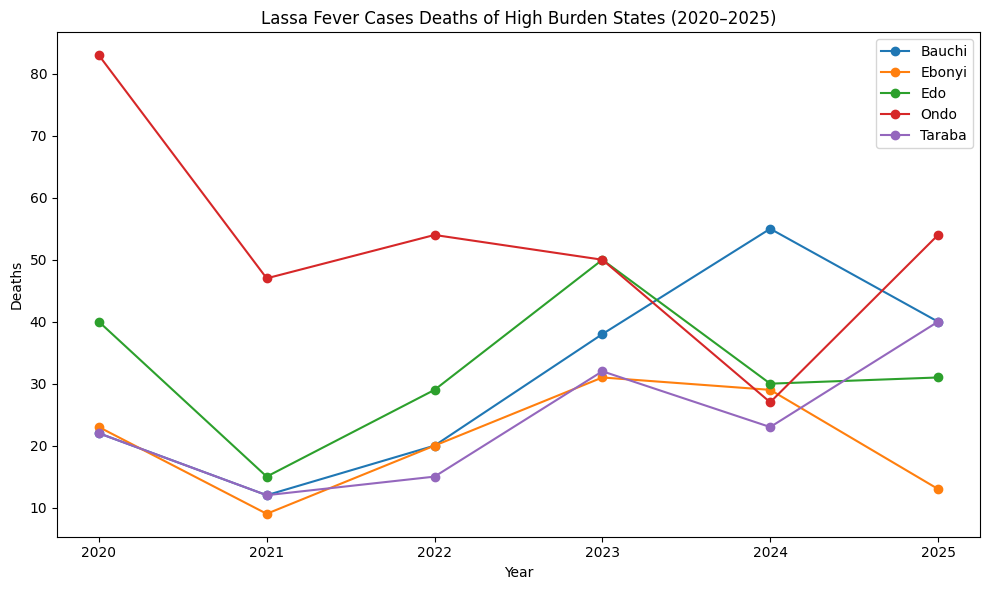

In [42]:
import matplotlib.pyplot as plt

pivot_confirmed = high_burden_state.pivot(index="year", columns="state_clean", values="deaths")

plt.figure(figsize=(10,6))
for zone in pivot_confirmed.columns:
    plt.plot(pivot_confirmed.index, pivot_confirmed[zone], marker="o", label=zone)

plt.xlabel("Year")
plt.ylabel("Deaths")
plt.title("Lassa Fever Cases Deaths of High Burden States (2020–2025)")
plt.legend()
plt.xticks(pivot_confirmed.index)
plt.tight_layout()
plt.show()

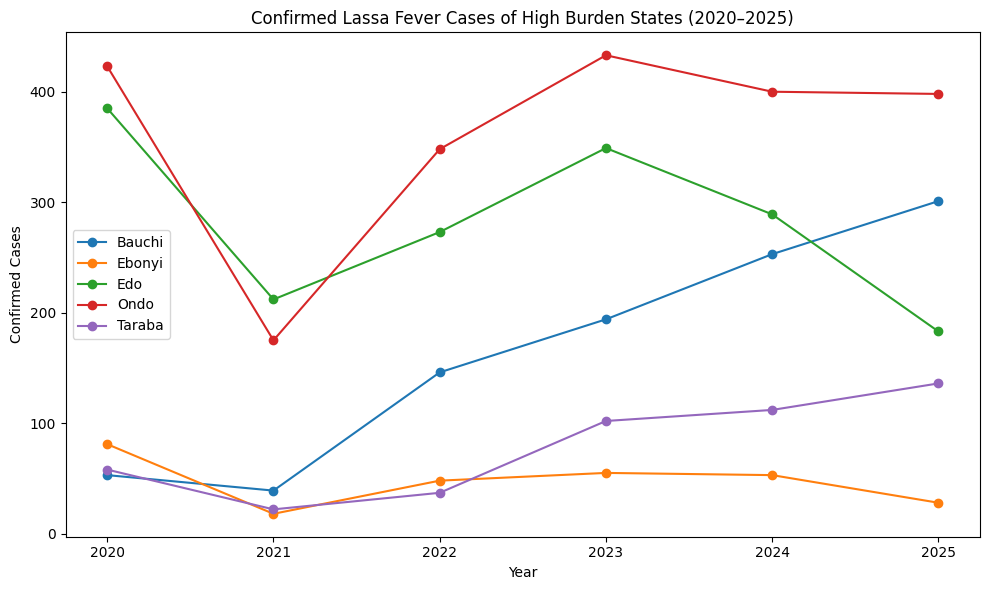

In [43]:
import matplotlib.pyplot as plt

pivot_confirmed = high_burden_state.pivot(index="year", columns="state_clean", values="confirmed")

plt.figure(figsize=(10,6))
for zone in pivot_confirmed.columns:
    plt.plot(pivot_confirmed.index, pivot_confirmed[zone], marker="o", label=zone)

plt.xlabel("Year")
plt.ylabel("Confirmed Cases")
plt.title("Confirmed Lassa Fever Cases of High Burden States (2020–2025)")
plt.legend()
plt.xticks(pivot_confirmed.index)
plt.tight_layout()
plt.show()

In [44]:
state_summary = gdf_summ.groupby(['state_clean'])[['suspected', 'confirmed',
                 'probable', 'confirmed_HCW_cases', 'deaths']].sum().sort_values(by='deaths', ascending=False)

state_summary.to_csv(r"..\data_files\final_datasets\State_summary_data.csv")
state_summary.head(2)

,suspected,confirmed,probable,confirmed_HCW_cases,deaths
state_clean,,,,,
Ondo,12428,2177,3,66,315
Edo,18588,1691,3,23,195


In [45]:
# gdf_map.drop(columns=['state_y', 'state_x'], inplace=True)
gdf_summ = gdf_summ[['state_clean'] + [c for c in gdf_summ.columns if c != 'state_clean']]

gdf_summ.to_file(r"..\data_files\final_datasets\clean_lassa_fever_map_data.geojson", driver="GeoJSON")


In [47]:
gdf_summ.to_file(r"..\data_files\final_datasets\clean_lassa_fever_map_data.geojson", driver="GeoJSON")

In [48]:
gdf_summ.head(2)

,state_clean,state,state_pcode,country,country_pcode,valid_on,area_sqkm,version,lang,center_lat,center_lon,geometry,suspected,confirmed,probable,confirmed_HCW_cases,deaths,geo_zone
0,Abia,Abia,NG001,Nigeria,NG,2019-04-17,4859.503138,v01,en,5.431820,7.488342,"POLYGON ((7.38681 6.03667, 7.38729 6.03605, 7....",148,6,0,0,2,South East
1,Adamawa,Adamawa,NG002,Nigeria,NG,2019-04-17,37971.674279,v01,en,9.140949,12.295110,"POLYGON ((13.62129 10.94823, 13.62592 10.94822...",98,9,0,0,1,North East
